In [1]:
import os
import random
import matplotlib as plt
from PIL import Image

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [5]:
data_dir = "archive"

classes = os.listdir(data_dir)
print("Classes:\n", *classes, sep="\n")

Classes:

Seahorse
Sea Urchins
Clams
Turtle_Tortoise
Dolphin
Jelly Fish
Penguin
Squid
Crabs
Lobster
Whale
Eel
Otter
Starfish
Seal
Puffers
Sea Rays
Sharks
Shrimp
Octopus
Fish
Corals
Nudibranchs


In [6]:
fish_classes = ["Fish", "Sharks", "Sea Rays", "Eel", "Puffers", "Dolphin", "Whale"]

In [8]:
import os
import shutil

source_dir = "archive"
target_dir = "fish-dataset"

os.makedirs(target_dir, exist_ok=True)
count = 0

for cls in fish_classes:
    cls_path = os.path.join(source_dir, cls)
    
    for img_name in os.listdir(cls_path):
        src = os.path.join(cls_path, img_name)
        dst = os.path.join(target_dir, f"{cls}_{img_name}") 
        
        try:
            shutil.copy(src, dst)
            count += 1
        except:
            pass

print("total fish images:", count)

total fish images: 3983


In [9]:
valid = 0
removed = 0

for file in os.listdir(target_dir):
    path = os.path.join(target_dir, file)
    
    try:
        img = Image.open(path).convert("RGB")
        valid += 1
    except:
        os.remove(path)
        removed += 1

print("valid:", valid)
print("removed:", removed)

valid: 3983
removed: 0


In [10]:
transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [12]:
#had to add this snippet because ImageFolder expects subdirectories for each class, but i have all images in one directory with prefixed names
root = "fish-dataset"
class_dir = os.path.join(root, "fish")

os.makedirs(class_dir, exist_ok=True)

for file in os.listdir(root):
    path = os.path.join(root, file)
    
    if os.path.isfile(path):
        shutil.move(path, os.path.join(class_dir, file))

In [13]:
dataset = ImageFolder("fish-dataset", transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
print("dataset size:", len(dataset))

dataset size: 3983


In [17]:
images, _ = next(iter(loader))
print(images.shape)   

torch.Size([64, 3, 128, 128])


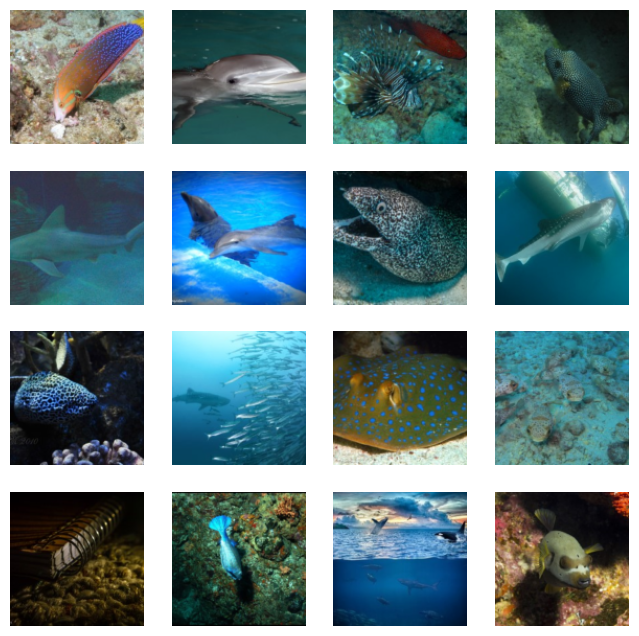

In [16]:
def show(images):
    images = images * 0.5 + 0.5    
    plt.figure(figsize=(8,8))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.axis("off")
    plt.show()
show(images)